In [1]:
from utils.config import DATA_DIR, SAVED_MODELS_DIR, RAW_CONFIG, _REPO_ROOT
from pathlib import Path
from models.Unet import UNet
from utils.datasetmonths import DatasetOverMonths, TestSubsetRegression
from torch.utils.data import DataLoader
from utils.splitter import test_indices
import torch
import numpy as np

In [2]:
cfg = RAW_CONFIG
data = DatasetOverMonths()

test_idx = test_indices(Path("../..") / cfg['monthly'][cfg['monthly']['training']['mode']]["test_indices"])
test_data = TestSubsetRegression(data, test_idx)

/mnt/c/Users/samue/SynologyDrive/OceanPropInfSatImg/monthly/small_sample_1993-1994.nc
Loaded existing test indices from ../../test_indices/small/num_1.pt, test size: 312800


In [3]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


In [4]:
model_path = SAVED_MODELS_DIR / "model: unet_regression training_start_time: 20250523_094055 datafile: 1993-10-11-1993-10-12.nc strat: 1993_test_stratification_larger_regions(10_img).pt"/"best_model"
model = torch.load(model_path, map_location=device, weights_only=False)
model.eval()

unet_regression

In [5]:
test_dataloader = torch.utils.data.DataLoader(
    test_data,
    batch_size=1,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)
len(next(iter(test_dataloader))) 

3

In [ ]:
after_model = []
num_samples = 150000

with torch.no_grad():
    for i, batch in enumerate(test_dataloader):
        images, labels, metadata = batch
        images_gpu = images.to(device)
        preds = model(images_gpu)
        batch_dict = {"image": images, "label": labels, "pred": preds, "grid" : metadata[0], "centre": metadata[1], "month": metadata[2]}
        after_model.append(batch_dict)
        if i % 10 == 0:
            print(f"Processed {i} batches")
        if i > num_samples:
            break


Processed 0 batches
Processed 10 batches
Processed 20 batches
Processed 30 batches
Processed 40 batches
Processed 50 batches
Processed 60 batches
Processed 70 batches
Processed 80 batches
Processed 10 batches
Processed 20 batches
Processed 30 batches
Processed 40 batches
Processed 50 batches
Processed 60 batches
Processed 70 batches
Processed 80 batches
Processed 90 batches
Processed 100 batches
Processed 110 batches
Processed 120 batches
Processed 130 batches
Processed 140 batches
Processed 150 batches
Processed 160 batches
Processed 170 batches
Processed 90 batches
Processed 100 batches
Processed 110 batches
Processed 120 batches
Processed 130 batches
Processed 140 batches
Processed 150 batches
Processed 160 batches
Processed 170 batches
Processed 180 batches
Processed 190 batches
Processed 200 batches
Processed 210 batches
Processed 220 batches
Processed 230 batches
Processed 240 batches
Processed 250 batches
Processed 180 batches
Processed 190 batches
Processed 200 batches
Processe

In [ ]:
months = tuple(set([month.item() for batch in after_model for month in batch["month"]]))
print(f"Months in the dataset: {months}")

Months in the dataset: (9, 11)


In [ ]:
mean, std = data.mean_label, data.std_label
for batch in after_model:
    batch["pred_unnorm"] = batch["pred"].cpu()
    batch["label_unnorm"] = (batch["label"] * std) + mean
    batch["pred_unnorm"] = (batch["pred_unnorm"] * std) + mean


In [ ]:
preds = [(batch["pred_unnorm"].item(), (batch["centre"][0].item(), batch["centre"][1].item())) for batch in after_model if batch["month"].item()== months[0]]
preds

[(13.377458572387695, (10, 10)),
 (13.322333335876465, (10, 11)),
 (13.266520500183105, (10, 12)),
 (13.214941024780273, (10, 13)),
 (13.165891647338867, (10, 14)),
 (13.122075080871582, (10, 15)),
 (13.081192016601562, (10, 16)),
 (13.049946784973145, (10, 17)),
 (13.015432357788086, (10, 18)),
 (12.982779502868652, (10, 19)),
 (12.953442573547363, (10, 20)),
 (12.926861763000488, (10, 21)),
 (12.897302627563477, (10, 22)),
 (12.868794441223145, (10, 23)),
 (12.845115661621094, (10, 24)),
 (12.815773010253906, (10, 25)),
 (12.790902137756348, (10, 26)),
 (12.764596939086914, (10, 27)),
 (12.740257263183594, (10, 28)),
 (12.720924377441406, (10, 29)),
 (12.703879356384277, (10, 30)),
 (12.698417663574219, (10, 31)),
 (12.693068504333496, (10, 32)),
 (12.69792652130127, (10, 33)),
 (12.705686569213867, (10, 34)),
 (12.722957611083984, (10, 35)),
 (12.745382308959961, (10, 36)),
 (12.776229858398438, (10, 37)),
 (12.81104850769043, (10, 38)),
 (12.85522747039795, (10, 39)),
 (12.90730190

In [ ]:
lat_range, lon_range = data.feature_map.shape[-2], data.feature_map.shape[-1]

In [ ]:
pred_map = np.zeros((lat_range, lon_range))

In [ ]:
for coord in preds:
    lat, lon = coord[1]
    pred_map[lat, lon] = coord[0]

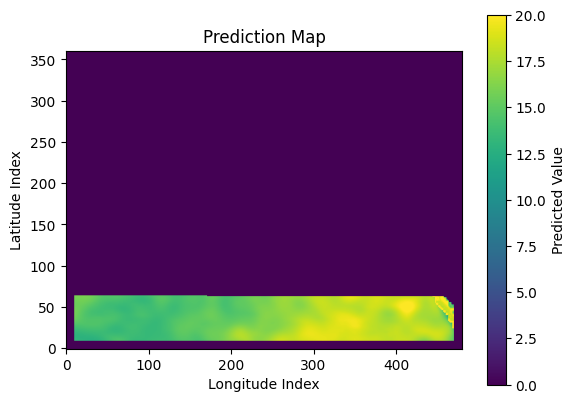

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(pred_map, origin='lower', vmin=0, vmax=20, cmap='viridis')
plt.title('Prediction Map')
plt.colorbar(label='Predicted Value')


plt.xlabel('Longitude Index')
plt.ylabel('Latitude Index')
plt.show()